Total rows: 50 (5 rounds x 10 entities)
Unique entities tested: 30


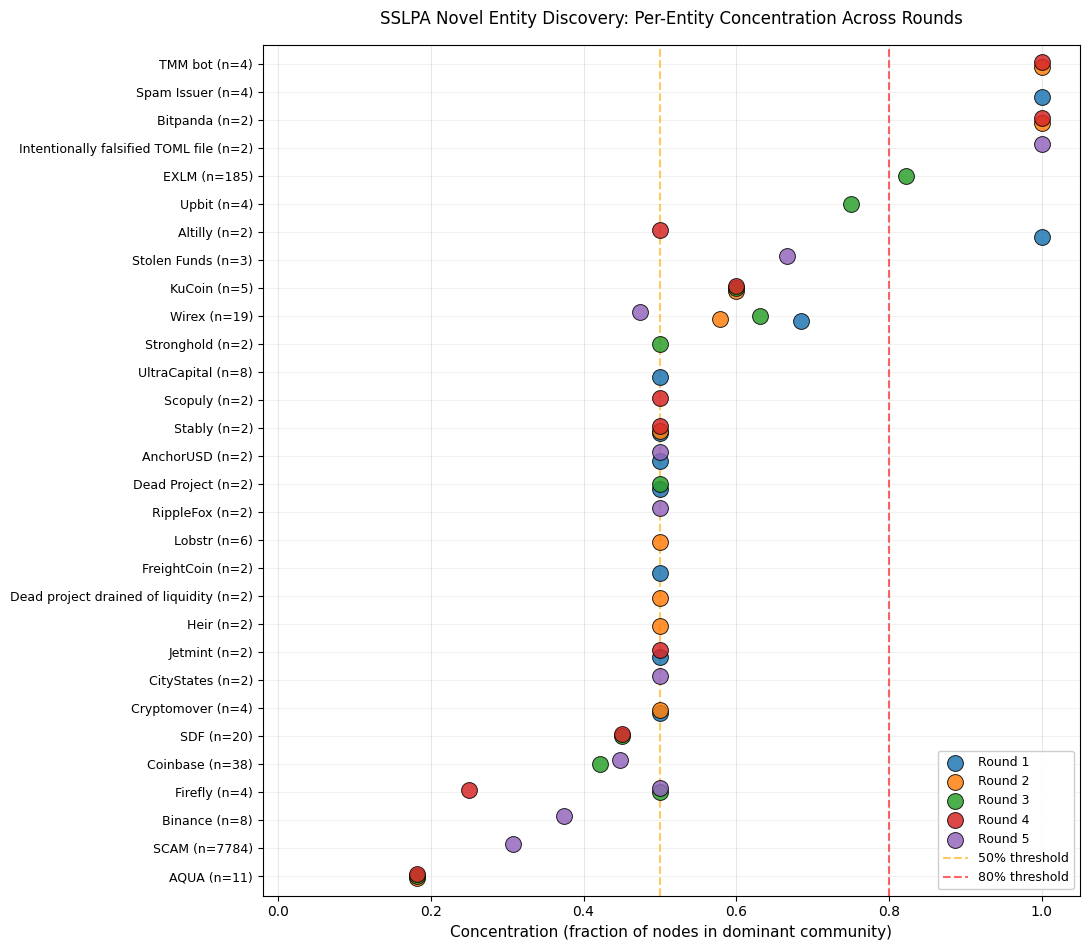

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.expanduser('')
df = pd.read_csv(os.path.join(RESULTS_DIR, 'novel_discovery_per_entity.csv'))

print(f'Total rows: {len(df)} (5 rounds x 10 entities)')
print(f'Unique entities tested: {df["true_label"].nunique()}')

# Compute per-entity average for sorting
entity_stats = (df.groupby('true_label')
                  .agg(mean_conc=('concentration', 'mean'),
                       num_nodes=('num_nodes', 'first'),
                       appearances=('round', 'count'))
                  .sort_values('mean_conc', ascending=True)
                  .reset_index())

# Give each entity a y-coordinate
entity_stats['y'] = np.arange(len(entity_stats))
df_plot = df.merge(entity_stats[['true_label', 'y']], on='true_label')

fig, ax = plt.subplots(figsize=(11, max(8, len(entity_stats) * 0.32)))

# One color per round
round_colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c',
                4: '#d62728', 5: '#9467bd'}

# Plot each round's points with vertical jitter so overlapping dots are visible
for r, color in round_colors.items():
    sub = df_plot[df_plot['round'] == r]
    jitter = (r - 3) * 0.08
    ax.scatter(sub['concentration'], sub['y'] + jitter,
               s=130, color=color, alpha=0.85,
               edgecolor='black', linewidth=0.7,
               label=f'Round {r}', zorder=3)

# # Black diamond = mean across rounds
# ax.scatter(entity_stats['mean_conc'], entity_stats['y'],
#            marker='D', s=90, color='black', zorder=5,
#            label='Mean across rounds')

# Faint horizontal guide per entity
for y in entity_stats['y']:
    ax.axhline(y=y, color='gray', alpha=0.15, linewidth=0.5, zorder=1)

# Threshold lines
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.6,
           label='50% threshold', zorder=2)
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.6,
           label='80% threshold', zorder=2)

# Y-axis labels: entity name + node count
ytick_labels = [f'{row.true_label} (n={row.num_nodes})'
                for _, row in entity_stats.iterrows()]
ax.set_yticks(entity_stats['y'])
ax.set_yticklabels(ytick_labels, fontsize=9)

ax.set_xlabel('Concentration (fraction of nodes in dominant community)', fontsize=11)
ax.set_title('SSLPA Novel Entity Discovery: Per-Entity Concentration Across Rounds',
             fontsize=12, pad=15)
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.7, len(entity_stats) - 0.3)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right', framealpha=0.95, fontsize=9)

plt.tight_layout()

os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'overview.png'),
            bbox_inches='tight', dpi=150)
plt.show()

Small entities (n=2): 14
Larger entities (n>2): 16


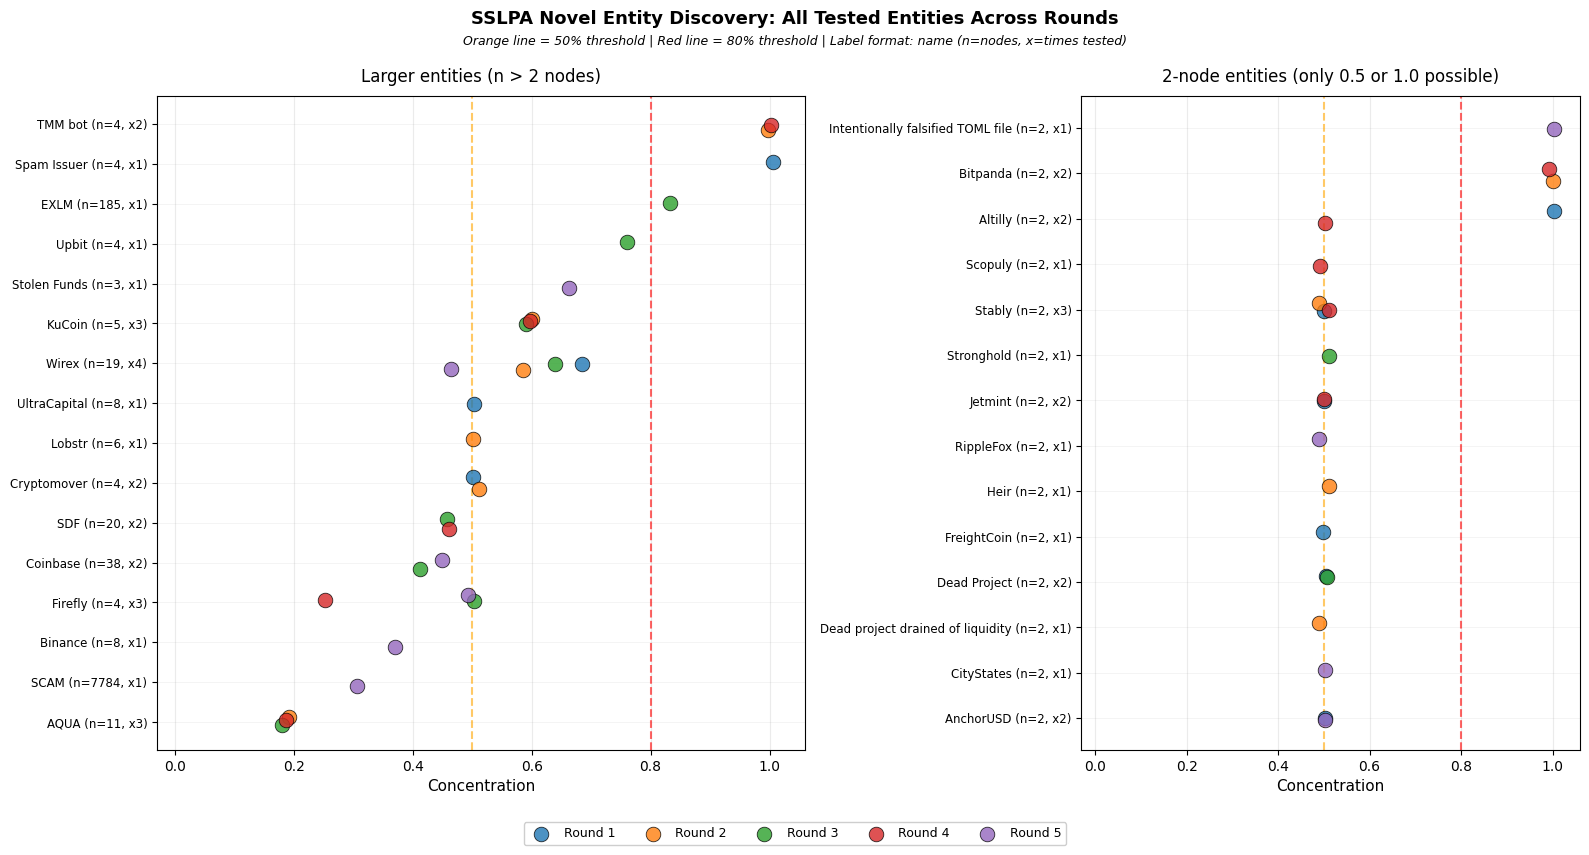

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.expanduser('')
df = pd.read_csv(os.path.join(RESULTS_DIR, 'novel_discovery_per_entity.csv'))

# Per-entity stats
entity_stats = (df.groupby('true_label')
                  .agg(mean_conc=('concentration', 'mean'),
                       num_nodes=('num_nodes', 'first'),
                       appearances=('round', 'count'))
                  .reset_index())

# Split into two panels by node count
small_entities = entity_stats[entity_stats['num_nodes'] <= 2].sort_values('mean_conc')
large_entities = entity_stats[entity_stats['num_nodes'] > 2].sort_values('mean_conc')

print(f'Small entities (n=2): {len(small_entities)}')
print(f'Larger entities (n>2): {len(large_entities)}')

round_colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c',
                4: '#d62728', 5: '#9467bd'}

fig, axes = plt.subplots(
    1, 2, figsize=(16, max(8, len(entity_stats) * 0.28)),
    gridspec_kw={'width_ratios': [1.3, 1]}
)

def plot_panel(ax, entities_df, title, df_full):
    entities_df = entities_df.reset_index(drop=True)
    entities_df['y'] = np.arange(len(entities_df))
    df_plot = df_full.merge(entities_df[['true_label', 'y']], on='true_label')

    # Faint horizontal guides
    for y in entities_df['y']:
        ax.axhline(y=y, color='gray', alpha=0.12, linewidth=0.5, zorder=1)

    # Threshold lines
    ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.6,
               linewidth=1.5, zorder=2)
    ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.6,
               linewidth=1.5, zorder=2)

    # Plot dots with jitter (both x and y) so overlaps become visible
    rng = np.random.RandomState(0)
    for r, color in round_colors.items():
        sub = df_plot[df_plot['round'] == r].copy()
        if len(sub) == 0:
            continue
        x_jitter = rng.uniform(-0.012, 0.012, size=len(sub))
        y_jitter = rng.uniform(-0.18, 0.18, size=len(sub))
        ax.scatter(sub['concentration'] + x_jitter,
                   sub['y'] + y_jitter,
                   s=110, color=color, alpha=0.8,
                   edgecolor='black', linewidth=0.6,
                   label=f'Round {r}', zorder=3)

    # Mean diamond
    # ax.scatter(entities_df['mean_conc'], entities_df['y'],
    #            marker='D', s=85, color='black', zorder=5,
    #            label='Mean')

    # Y-axis labels
    ytick_labels = [f'{row.true_label} (n={row.num_nodes}, x{row.appearances})'
                    for _, row in entities_df.iterrows()]
    ax.set_yticks(entities_df['y'])
    ax.set_yticklabels(ytick_labels, fontsize=8.5)

    ax.set_xlabel('Concentration', fontsize=11)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlim(-0.03, 1.06)
    ax.set_ylim(-0.7, len(entities_df) - 0.3)
    ax.grid(axis='x', alpha=0.25)

# Left panel: larger entities (more informative, more variation possible)
plot_panel(axes[0], large_entities,
           'Larger entities (n > 2 nodes)', df)

# Right panel: 2-node entities (only 0.5 or 1.0 possible)
plot_panel(axes[1], small_entities,
           '2-node entities (only 0.5 or 1.0 possible)', df)

# Single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
# Deduplicate
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
fig.legend([h for h, l in unique], [l for h, l in unique],
           loc='lower center', ncol=7, bbox_to_anchor=(0.5, -0.02),
           fontsize=9, framealpha=0.95)

# Add threshold annotations
fig.text(0.5, 0.965,
         'SSLPA Novel Entity Discovery: All Tested Entities Across Rounds',
         ha='center', fontsize=13, weight='bold')
fig.text(0.5, 0.94,
         'Orange line = 50% threshold | Red line = 80% threshold | '
         'Label format: name (n=nodes, x=times tested)',
         ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])

os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'overview_split.png'),
            bbox_inches='tight', dpi=150)
plt.show()

/tmp/ipykernel_2313373/1125008257.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_by_bucket, labels=bucket_order,
/tmp/ipykernel_2313373/1125008257.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(data_by_round, labels=[f'Round {r}' for r in rounds],


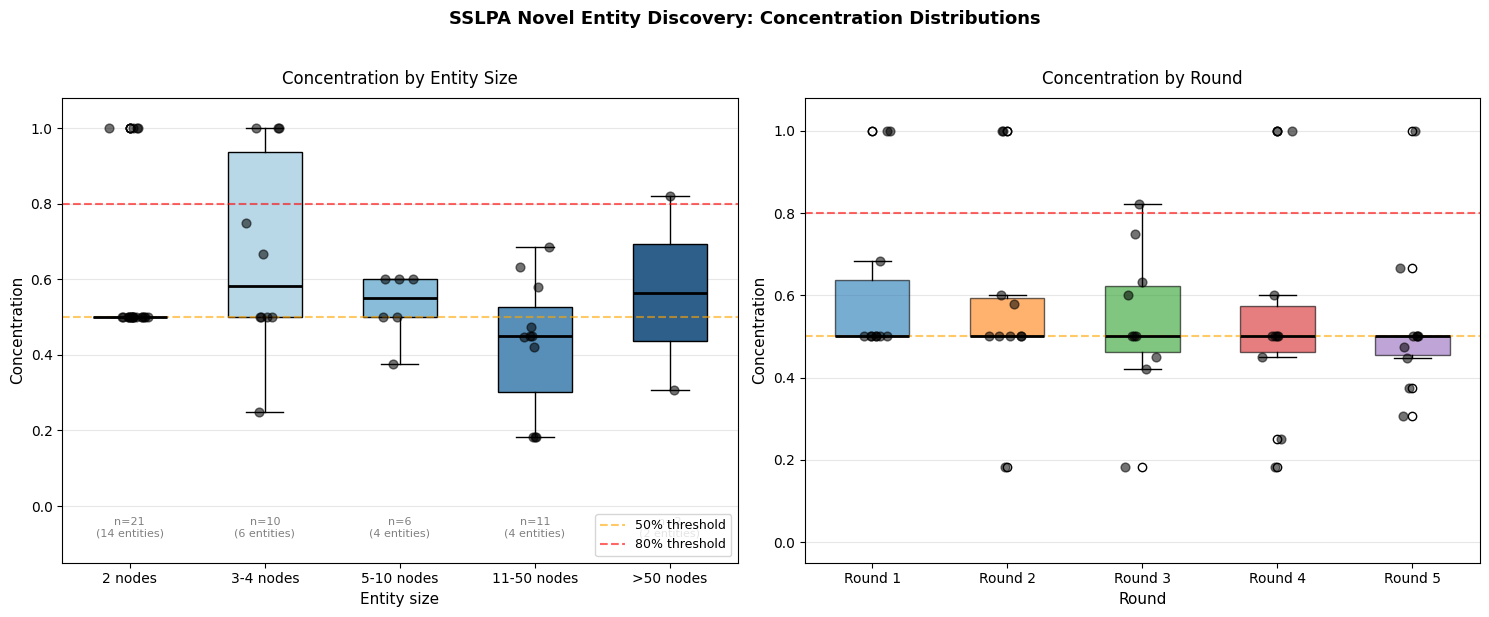


Stats per size bucket:
                 mean    median       std  count
size_bucket                                     
11-50 nodes  0.425663  0.450000  0.177513     11
2 nodes      0.595238  0.500000  0.201187     21
3-4 nodes    0.666667  0.583333  0.263523     10
5-10 nodes   0.529167  0.550000  0.090023      6
>50 nodes    0.564459  0.564459  0.363682      2


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.expanduser('')
df = pd.read_csv(os.path.join(RESULTS_DIR, 'novel_discovery_per_entity.csv'))

# Bucket entities by size
def size_bucket(n):
    if n == 2:
        return '2 nodes'
    elif n <= 4:
        return '3-4 nodes'
    elif n <= 10:
        return '5-10 nodes'
    elif n <= 50:
        return '11-50 nodes'
    else:
        return '>50 nodes'

df['size_bucket'] = df['num_nodes'].apply(size_bucket)
bucket_order = ['2 nodes', '3-4 nodes', '5-10 nodes', '11-50 nodes', '>50 nodes']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ─────────────────────────────────────────────────────────────────
# Left: Box plot by size bucket
# ─────────────────────────────────────────────────────────────────
data_by_bucket = [df[df['size_bucket'] == b]['concentration'].values
                  for b in bucket_order]

bp = ax1.boxplot(data_by_bucket, labels=bucket_order,
                 patch_artist=True, widths=0.55,
                 medianprops=dict(color='black', linewidth=2),
                 boxprops=dict(linewidth=1),
                 whiskerprops=dict(linewidth=1),
                 capprops=dict(linewidth=1))

# Color boxes
colors = ['#E8F4F8', '#B8D8E8', '#88BCD8', '#588FB8', '#2E5F8A']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Overlay individual points
for i, b in enumerate(bucket_order):
    sub = df[df['size_bucket'] == b]
    x_jitter = np.random.RandomState(i).normal(i + 1, 0.06, size=len(sub))
    ax1.scatter(x_jitter, sub['concentration'],
                s=40, color='black', alpha=0.55, zorder=3)

# Annotate each bucket with count
for i, b in enumerate(bucket_order):
    n_obs = len(df[df['size_bucket'] == b])
    n_ent = df[df['size_bucket'] == b]['true_label'].nunique()
    ax1.text(i + 1, -0.08, f'n={n_obs}\n({n_ent} entities)',
             ha='center', fontsize=8, color='gray')

ax1.axhline(y=0.5, color='orange', linestyle='--', alpha=0.6, label='50% threshold')
ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.6, label='80% threshold')
ax1.set_ylabel('Concentration', fontsize=11)
ax1.set_xlabel('Entity size', fontsize=11)
ax1.set_title('Concentration by Entity Size', fontsize=12, pad=10)
ax1.set_ylim(-0.15, 1.08)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────────────────────────────
# Right: Box plot by round
# ─────────────────────────────────────────────────────────────────
rounds = sorted(df['round'].unique())
data_by_round = [df[df['round'] == r]['concentration'].values for r in rounds]

bp2 = ax2.boxplot(data_by_round, labels=[f'Round {r}' for r in rounds],
                  patch_artist=True, widths=0.55,
                  medianprops=dict(color='black', linewidth=2))

round_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for patch, color in zip(bp2['boxes'], round_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay individual points
for i, r in enumerate(rounds):
    sub = df[df['round'] == r]
    x_jitter = np.random.RandomState(i).normal(i + 1, 0.06, size=len(sub))
    ax2.scatter(x_jitter, sub['concentration'],
                s=40, color='black', alpha=0.55, zorder=3)

ax2.axhline(y=0.5, color='orange', linestyle='--', alpha=0.6)
ax2.axhline(y=0.8, color='red', linestyle='--', alpha=0.6)
ax2.set_ylabel('Concentration', fontsize=11)
ax2.set_xlabel('Round', fontsize=11)
ax2.set_title('Concentration by Round', fontsize=12, pad=10)
ax2.set_ylim(-0.05, 1.08)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('SSLPA Novel Entity Discovery: Concentration Distributions',
             fontsize=13, y=1.02, weight='bold')

plt.tight_layout()

os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'boxplots.png'),
            bbox_inches='tight', dpi=150)
plt.show()

# Print stats per bucket
print("\nStats per size bucket:")
print(df.groupby('size_bucket')['concentration'].agg(['mean', 'median', 'std', 'count']))

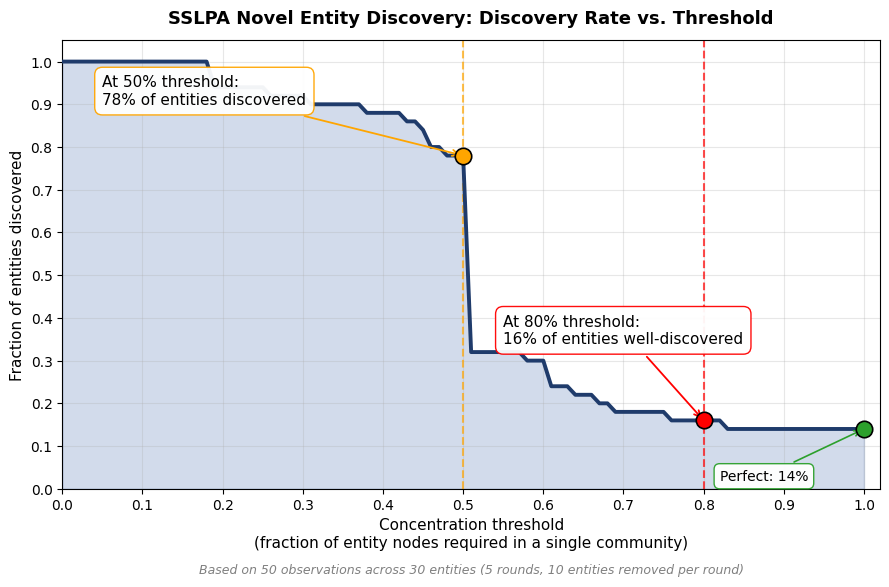


Key discovery rates:
  Concentration >= 0.3: 92.0%  (46/50 observations)
  Concentration >= 0.5: 78.0%  (39/50 observations)
  Concentration >= 0.7: 18.0%  (9/50 observations)
  Concentration >= 0.8: 16.0%  (8/50 observations)
  Concentration >= 0.9: 14.0%  (7/50 observations)
  Concentration >= 1.0: 14.0%  (7/50 observations)


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.expanduser('')
df = pd.read_csv(os.path.join(RESULTS_DIR, 'novel_discovery_per_entity.csv'))

# Compute the discovery curve: for each threshold t, what fraction of
# entity-round observations had concentration >= t?
thresholds = np.linspace(0, 1, 101)
discovery_rate = [(df['concentration'] >= t).mean() for t in thresholds]

# Key reference points for annotation
rate_at_50 = (df['concentration'] >= 0.5).mean()
rate_at_80 = (df['concentration'] >= 0.8).mean()
rate_at_100 = (df['concentration'] >= 1.0).mean()

fig, ax = plt.subplots(figsize=(9, 6))

# Fill area under curve for visual weight
ax.fill_between(thresholds, 0, discovery_rate,
                color='#4C72B0', alpha=0.25)
ax.plot(thresholds, discovery_rate,
        color='#1f3b6b', linewidth=2.8, zorder=3)

# Mark 50% threshold
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, linewidth=1.5)
ax.scatter([0.5], [rate_at_50], s=140, color='orange',
           edgecolor='black', linewidth=1.2, zorder=5)
ax.annotate(f'At 50% threshold:\n{rate_at_50:.0%} of entities discovered',
            xy=(0.5, rate_at_50),
            xytext=(-120, 80),
            fontsize=11, ha='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='orange', alpha=0.95),
            arrowprops=dict(arrowstyle='->', color='orange', lw=1.3))

# Mark 80% threshold
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax.scatter([0.8], [rate_at_80], s=140, color='red',
           edgecolor='black', linewidth=1.2, zorder=5)
ax.annotate(f'At 80% threshold:\n{rate_at_80:.0%} of entities well-discovered',
            xy=(0.8, rate_at_80),
            xytext=(0.55, rate_at_80 + 0.18),
            fontsize=11, ha='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='red', alpha=0.95),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.3))

# Mark 100% (perfect discovery)
ax.scatter([1.0], [rate_at_100], s=140, color='#2CA02C',
           edgecolor='black', linewidth=1.2, zorder=5)
ax.annotate(f'Perfect: {rate_at_100:.0%}',
            xy=(1.0, rate_at_100),
            xytext=(0.82, rate_at_100 - 0.12),
            fontsize=10, ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#2CA02C', alpha=0.95),
            arrowprops=dict(arrowstyle='->', color='#2CA02C', lw=1.2))

ax.set_xlabel('Concentration threshold\n(fraction of entity nodes required in a single community)',
              fontsize=11)
ax.set_ylabel('Fraction of entities discovered', fontsize=11)
ax.set_title('SSLPA Novel Entity Discovery: Discovery Rate vs. Threshold',
             fontsize=13, pad=12, weight='bold')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.grid(alpha=0.3)

# Explanatory subtitle
n_obs = len(df)
n_entities = df['true_label'].nunique()
ax.text(0.5, -0.19,
        f'Based on {n_obs} observations across {n_entities} entities '
        f'(5 rounds, 10 entities removed per round)',
        transform=ax.transAxes, ha='center', fontsize=9,
        style='italic', color='gray')

plt.tight_layout()

os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'discovery_curve.png'),
            bbox_inches='tight', dpi=150)
plt.show()

# Print the numbers for the paper
print("\nKey discovery rates:")
for t in [0.3, 0.5, 0.7, 0.8, 0.9, 1.0]:
    rate = (df['concentration'] >= t).mean()
    count = (df['concentration'] >= t).sum()
    print(f"  Concentration >= {t:.1f}: {rate:.1%}  ({count}/{n_obs} observations)")